# Posterior Model Verification: GAM vs Kalshi

Compare our GAM in-game win probability model against Kalshi market-implied odds
across all 2025-26 NBA games where both PBP and Kalshi data are available.

For each game we:
1. Build game states from PBP data (same pipeline as posterior_modeling4)
2. Generate model predictions (raw, postprocessed, calibrated)
3. Interpolate Kalshi implied odds to align with PBP event timestamps
4. Evaluate both against actual outcomes using log loss, Brier score, and ECE

In [1]:
import sys, os
os.chdir(os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.')

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pygam import LogisticGAM, te, l, s
from sklearn.isotonic import IsotonicRegression

BASE_DIR = Path('.').resolve()
DATA_DIR = BASE_DIR / 'data'
ARTIFACTS_DIR = BASE_DIR / 'artifacts'

REG_PERIOD_SEC = 720
OT_PERIOD_SEC  = 300
TOTAL_REG_SEC  = 4 * REG_PERIOD_SEC

print(f'Data: {DATA_DIR}')
print(f'Artifacts: {ARTIFACTS_DIR}')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Data: /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/data
Artifacts: /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/artifacts


## Step 1 -- Load Model & Define Feature Pipeline

Reuse all feature functions from posterior_modeling4, load saved GAM + calibration artifacts.

In [2]:
# -- Feature functions (same as posterior_modeling4) --

GAM_REG_FEATURES = [
    "score_diff", "t_reg_norm", "pregame_logit",
    "efg_diff", "ts_diff", "off_rtg_diff",
    "ast_diff", "tov_diff", "reb_diff", "net_pts_last_120",
    "foul_diff", "ft_pct_diff", "timeout_diff",
    "bonus_diff", "is_home_poss_signed",
    "rest_diff", "roster_quality_diff", "win_pct_diff",
    "stl_diff", "blk_diff", "oreb_diff", "fg3_pct_diff", "fta_rate_diff",
]
GAM_OT_FEATURES = [
    "score_diff", "t_ot_norm", "pregame_logit", "ot_number",
    "efg_diff", "ts_diff", "off_rtg_diff",
    "ast_diff", "tov_diff", "reb_diff", "net_pts_last_120",
    "foul_diff", "ft_pct_diff", "timeout_diff",
    "bonus_diff", "is_home_poss_signed",
    "rest_diff", "roster_quality_diff", "win_pct_diff",
    "stl_diff", "blk_diff", "oreb_diff", "fg3_pct_diff", "fta_rate_diff",
]

TAU_DEFAULT = 200  # decay half-life in total possessions

def load_season_baselines(data_dir=None):
    if data_dir is None:
        data_dir = DATA_DIR
    tg2 = pd.read_csv(data_dir / "training_games2.csv", dtype={"game_id": str}, low_memory=False)
    tg2["game_id"] = tg2["game_id"].astype(str).str.strip()
    baselines = pd.DataFrame({"game_id": tg2["game_id"]})
    for side in ["home", "away"]:
        fgm = pd.to_numeric(tg2[f"{side}_FGM"], errors="coerce").fillna(0)
        fga = pd.to_numeric(tg2[f"{side}_FGA"], errors="coerce").fillna(0).clip(lower=1)
        fg3m = pd.to_numeric(tg2[f"{side}_FG3M"], errors="coerce").fillna(0)
        pts = pd.to_numeric(tg2[f"{side}_PTS"], errors="coerce").fillna(0)
        fta = pd.to_numeric(tg2[f"{side}_FTA"], errors="coerce").fillna(0)
        ft_pct = pd.to_numeric(tg2[f"{side}_FT_PCT"], errors="coerce").fillna(0)
        oreb = pd.to_numeric(tg2[f"{side}_OREB"], errors="coerce").fillna(0)
        to = pd.to_numeric(tg2[f"{side}_TO"], errors="coerce").fillna(0)
        baselines[f"season_{side}_efg"] = (fgm + 0.5 * fg3m) / fga
        baselines[f"season_{side}_ts"] = pts / (2 * (fga + 0.44 * fta)).clip(lower=1)
        poss = (fga + 0.44 * fta - oreb + to).clip(lower=1)
        baselines[f"season_{side}_off_rtg"] = 100 * pts / poss
        baselines[f"season_{side}_ft_pct"] = ft_pct
    baselines = baselines.set_index("game_id")
    return baselines

def load_prior_features(data_dir=None):
    if data_dir is None:
        data_dir = DATA_DIR
    tg4 = pd.read_csv(data_dir / "training_games4.csv", dtype={"game_id": str},
                       usecols=["game_id", "home_days_rest", "away_days_rest",
                                "home_10g_player_PLUS_MINUS", "away_10g_player_PLUS_MINUS",
                                "home_win_pct", "away_win_pct"],
                       low_memory=False)
    tg4["game_id"] = tg4["game_id"].astype(str).str.strip()
    tg4["rest_diff"] = tg4["home_days_rest"].fillna(0) - tg4["away_days_rest"].fillna(0)
    tg4["roster_quality_diff"] = tg4["home_10g_player_PLUS_MINUS"].fillna(0) - tg4["away_10g_player_PLUS_MINUS"].fillna(0)
    tg4["win_pct_diff"] = tg4["home_win_pct"].fillna(0.5) - tg4["away_win_pct"].fillna(0.5)
    return tg4[["game_id", "rest_diff", "roster_quality_diff", "win_pct_diff"]].set_index("game_id")


def compute_prior_logit(df):
    df = df.copy()
    p0 = df["prior_home_wp"].clip(0.001, 0.999)
    df["pregame_logit"] = np.log(p0 / (1.0 - p0))
    return df

def compute_time_features(df):
    df = df.copy()
    period = df["period_number"].astype(int)
    sec_period = pd.to_numeric(df["sec_remaining_period"], errors="coerce").fillna(0).astype(float)
    df["is_ot"] = (period > 4).astype(int)
    df["ot_number"] = np.clip(period - 4, 0, None)
    df["t_reg_remaining"] = np.where(
        period <= 4, (4 - period) * REG_PERIOD_SEC + sec_period, 0
    ).astype(float)
    df["t_ot_remaining"] = np.where(period > 4, sec_period, 0).astype(float)
    df["t_reg_norm"] = df["t_reg_remaining"] / TOTAL_REG_SEC
    df["t_ot_norm"] = np.where(
        df["is_ot"] == 1, df["t_ot_remaining"] / OT_PERIOD_SEC, 0.0
    )
    df["elapsed_game_seconds"] = np.where(
        period <= 4,
        (period - 1) * REG_PERIOD_SEC + (REG_PERIOD_SEC - sec_period),
        TOTAL_REG_SEC + (df["ot_number"] - 1) * OT_PERIOD_SEC + (OT_PERIOD_SEC - sec_period),
    ).astype(float)
    return df

def compute_score_diff(df):
    df = df.copy()
    if "score_diff" not in df.columns:
        df["score_diff"] = (
            pd.to_numeric(df["home_score"], errors="coerce").fillna(0).astype(int)
            - pd.to_numeric(df["away_score"], errors="coerce").fillna(0).astype(int)
        )
    return df

def compute_quality_diffs(df, tau=TAU_DEFAULT):
    df = df.copy()
    if tau and tau > 0 and "season_home_efg" in df.columns:
        total_poss = (df.get("home_poss_to_date", pd.Series(0, index=df.index)).fillna(0)
                      + df.get("away_poss_to_date", pd.Series(0, index=df.index)).fillna(0))
        w = np.exp(-total_poss / tau)
    else:
        w = 0.0
    for feat, season_col, ingame_col in [
        ("efg", "season_{side}_efg", "{side}_efg_pct"),
        ("ts", "season_{side}_ts", "{side}_ts_pct"),
        ("off_rtg", "season_{side}_off_rtg", "{side}_off_rtg"),
    ]:
        for side in ["home", "away"]:
            s_col = season_col.format(side=side)
            i_col = ingame_col.format(side=side)
            ingame = df[i_col].fillna(0)
            if isinstance(w, float) and w == 0.0:
                df[f"_blended_{side}_{feat}"] = ingame
            else:
                season = df.get(s_col, pd.Series(np.nan, index=df.index))
                has_season = season.notna()
                blended = np.where(has_season, w * season.fillna(0) + (1 - w) * ingame, ingame)
                df[f"_blended_{side}_{feat}"] = blended
    df["efg_diff"] = df["_blended_home_efg"] - df["_blended_away_efg"]
    df["ts_diff"] = df["_blended_home_ts"] - df["_blended_away_ts"]
    df["off_rtg_diff"] = df["_blended_home_off_rtg"] - df["_blended_away_off_rtg"]
    df = df.drop(columns=[c for c in df.columns if c.startswith("_blended_")])
    df["ast_diff"] = df["home_ast_to_date"].fillna(0) - df["away_ast_to_date"].fillna(0)
    df["tov_diff"] = df["away_tov_to_date"].fillna(0) - df["home_tov_to_date"].fillna(0)
    df["reb_diff"] = (
        (df["home_oreb_to_date"].fillna(0) + df["home_dreb_to_date"].fillna(0))
        - (df["away_oreb_to_date"].fillna(0) + df["away_dreb_to_date"].fillna(0))
    )
    if "net_pts_last_120" not in df.columns:
        df["net_pts_last_120"] = 0.0
    return df

def compute_late_diffs(df, tau=TAU_DEFAULT):
    df = df.copy()
    df["foul_diff"] = df["away_pf_to_date"].fillna(0) - df["home_pf_to_date"].fillna(0)
    if tau and tau > 0 and "season_home_ft_pct" in df.columns:
        total_poss = (df.get("home_poss_to_date", pd.Series(0, index=df.index)).fillna(0)
                      + df.get("away_poss_to_date", pd.Series(0, index=df.index)).fillna(0))
        w = np.exp(-total_poss / tau)
        home_ft = df["home_ft_pct"].fillna(0)
        away_ft = df["away_ft_pct"].fillna(0)
        s_home = df.get("season_home_ft_pct", pd.Series(np.nan, index=df.index))
        s_away = df.get("season_away_ft_pct", pd.Series(np.nan, index=df.index))
        has_home = s_home.notna()
        has_away = s_away.notna()
        b_home = np.where(has_home, w * s_home.fillna(0) + (1 - w) * home_ft, home_ft)
        b_away = np.where(has_away, w * s_away.fillna(0) + (1 - w) * away_ft, away_ft)
        df["ft_pct_diff"] = b_home - b_away
    else:
        df["ft_pct_diff"] = df["home_ft_pct"].fillna(0) - df["away_ft_pct"].fillna(0)
    df["timeout_diff"] = df["away_timeouts_called"].fillna(0) - df["home_timeouts_called"].fillna(0)
    return df

def compute_bonus_features(df):
    df = df.copy()
    home_pf = df["home_pf_to_date"].fillna(0)
    away_pf = df["away_pf_to_date"].fillna(0)
    period_start_home = df.groupby(["game_id", "period_number"])["home_pf_to_date"].transform("min").fillna(0)
    period_start_away = df.groupby(["game_id", "period_number"])["away_pf_to_date"].transform("min").fillna(0)
    home_pf_period = home_pf - period_start_home
    away_pf_period = away_pf - period_start_away
    threshold = np.where(df["period_number"] > 4, 4, 5)
    home_in_bonus = (away_pf_period >= threshold).astype(int)
    away_in_bonus = (home_pf_period >= threshold).astype(int)
    df["bonus_diff"] = home_in_bonus - away_in_bonus
    return df

def compute_possession(df):
    df = df.copy()
    poss = df["is_home_possession"].values.copy().astype(float)
    df["is_home_poss_signed"] = np.where(
        np.isnan(poss), 0.0, np.where(poss == 0, -1.0, 1.0)
    )
    return df


def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

def _logit(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1.0 - p))

def postprocess_predictions(p_raw, df, prior_alpha=2.0, terminal_sec=30.0):
    p_raw = np.asarray(p_raw, dtype=float)
    pregame_logit = df["pregame_logit"].values.astype(float)
    t_reg_norm = df["t_reg_norm"].values.astype(float)
    is_ot = df["is_ot"].values.astype(int)
    t_reg_remaining = df["t_reg_remaining"].values.astype(float)
    t_ot_remaining = df["t_ot_remaining"].values.astype(float)
    score_diff = df["score_diff"].values.astype(float)
    prior_weight = np.where(is_ot == 0, np.power(t_reg_norm, prior_alpha), 0.0)
    raw_logit = _logit(p_raw)
    blended_logit = prior_weight * pregame_logit + (1.0 - prior_weight) * raw_logit
    p = _sigmoid(blended_logit)
    time_remaining = np.where(is_ot == 0, t_reg_remaining, t_ot_remaining)
    terminal_mask = (time_remaining < terminal_sec) & (score_diff != 0)
    if terminal_mask.any():
        terminal_weight = 1.0 - time_remaining[terminal_mask] / terminal_sec
        deterministic = np.where(score_diff[terminal_mask] > 0, 1.0, 0.0)
        p[terminal_mask] = (1.0 - terminal_weight) * p[terminal_mask] + terminal_weight * deterministic
    return np.clip(p, 1e-7, 1 - 1e-7)


# -- Metrics --

def weighted_log_loss(y, p, w):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    losses = -(y * np.log(p) + (1 - y) * np.log(1 - p))
    return float(np.average(losses, weights=w))

def weighted_brier(y, p, w):
    return float(np.average((y - p) ** 2, weights=w))

def expected_calibration_error(y, p, w, n_bins=20):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    total_w = w.sum()
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if not mask.any():
            continue
        bw = w[mask].sum()
        avg_p = np.average(p[mask], weights=w[mask])
        avg_y = np.average(y[mask], weights=w[mask])
        ece += (bw / total_w) * abs(avg_y - avg_p)
    return float(ece)

def reliability_curve(y, p, w, n_bins=20):
    bins = np.linspace(0, 1, n_bins + 1)
    centers, empirical, weights = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if not mask.any():
            continue
        centers.append((lo + hi) / 2)
        empirical.append(np.average(y[mask], weights=w[mask]))
        weights.append(w[mask].sum())
    return np.array(centers), np.array(empirical), np.array(weights)


print('Feature pipeline and metrics defined.')

Feature pipeline and metrics defined.


In [3]:
# -- Load saved model artifacts --

reg_gam = joblib.load(ARTIFACTS_DIR / 'gam_reg.pkl')
ot_gam  = joblib.load(ARTIFACTS_DIR / 'gam_ot.pkl')
iso_gam = joblib.load(ARTIFACTS_DIR / 'iso_gam.pkl')
iso_gam_post = joblib.load(ARTIFACTS_DIR / 'iso_gam_post.pkl')

# Postprocess params (from posterior_modeling4 tuning)
_gam_config = joblib.load(ARTIFACTS_DIR / 'gam_config.pkl')
BLEND_TAU = _gam_config.get('tau', 0)
GAM_ALPHA = 2.0
GAM_TSEC  = 30.0
print(f'Blend tau = {BLEND_TAU}')


def gam_predict(df):
    p = np.full(len(df), 0.5)
    reg_mask = df["is_ot"] == 0
    ot_mask = df["is_ot"] == 1
    if reg_gam is not None and reg_mask.any():
        X = df.loc[reg_mask, GAM_REG_FEATURES].values.astype(float)
        p[reg_mask.values] = reg_gam.predict_proba(X)
    if ot_gam is not None and ot_mask.any():
        X = df.loc[ot_mask, GAM_OT_FEATURES].values.astype(float)
        p[ot_mask.values] = ot_gam.predict_proba(X)
    return np.clip(p, 1e-7, 1 - 1e-7)

def gam_predict_post(df):
    p_raw = gam_predict(df)
    return postprocess_predictions(p_raw, df, GAM_ALPHA, GAM_TSEC)

def gam_predict_post_cal(df):
    p_post = gam_predict_post(df)
    return iso_gam_post.predict(p_post)


print('Models loaded.')

Blend tau = 200
Models loaded.


/Users/danielyang/anaconda3/envs/prediction-trader/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Step 2 -- Build Game States & Kalshi Alignment

For each game with both PBP and Kalshi data:
1. Build game features from PBP (same `build_game_from_pbp` pipeline)
2. Compute model predictions at each PBP event
3. Interpolate Kalshi implied odds onto PBP event timestamps
4. Weight each row by time until next event (same as training)

In [4]:
# -- Game builder (from posterior_modeling4) --

def load_game_predictions(path=None):
    if path is None:
        path = DATA_DIR / "games_predictions.csv"
    df = pd.read_csv(path, dtype={"game_id": str})
    df["game_id"] = df["game_id"].astype(str).str.strip()
    df["prior_home_wp"] = pd.to_numeric(df["prior_home_wp"], errors="coerce")
    return df

GAME_PREDS = load_game_predictions()
SEASON_BASELINES = load_season_baselines()
PRIOR_FEATURES = load_prior_features()
print(f'Season baselines: {len(SEASON_BASELINES)} games')
print(f'Prior features: {len(PRIOR_FEATURES)} games')

def build_game_from_pbp(game_id, data_dir=DATA_DIR):
    pbp_path = list((data_dir / 'games_live' / '2026').glob(f'{game_id}_*.csv'))[0]
    pbp = pd.read_csv(pbp_path).sort_values('game_play_number').reset_index(drop=True)

    end_period_mask = pbp['type_text'].str.contains('End Period', na=False)
    pbp.loc[end_period_mask, 'end_quarter_seconds_remaining'] = 0.0

    home_tid = pbp['home_team_id'].iloc[0]
    away_tid = pbp['away_team_id'].iloc[0]
    is_home = pbp['team_id'] == home_tid
    is_away = pbp['team_id'] == away_tid

    fg_att  = pbp['shooting_play'].fillna(False) & (pbp['points_attempted'] >= 2)
    fg_made = pbp['scoring_play'].fillna(False) & (pbp['score_value'] >= 2)
    fg3_made = pbp['scoring_play'].fillna(False) & (pbp['score_value'] == 3)
    ft_att  = pbp['shooting_play'].fillna(False) & (pbp['points_attempted'] == 1)
    ft_made = pbp['scoring_play'].fillna(False) & (pbp['score_value'] == 1)
    oreb = pbp['type_text'].str.contains('Offensive Rebound', na=False)
    dreb = pbp['type_text'].str.contains('Defensive Rebound', na=False)
    tov  = pbp['short_description'].str.contains('Turnover', na=False)
    ast  = pbp['text'].str.contains('assists', case=False, na=False) & pbp['scoring_play'].fillna(False)
    foul = pbp['short_description'].str.contains('Foul', na=False)
    timeout = pbp['short_description'].str.contains('Timeout', na=False)
    steal = pbp['type_text'].str.contains('Steal', na=False)
    block = pbp['type_text'].str.contains('Block', na=False)

    cols = {}
    for prefix, mask in [('home', is_home), ('away', is_away)]:
        cols[f'{prefix}_fga_to_date'] = (fg_att & mask).cumsum()
        cols[f'{prefix}_fgm_to_date'] = (fg_made & mask).cumsum()
        cols[f'{prefix}_fg3m_to_date'] = (fg3_made & mask).cumsum()
        cols[f'{prefix}_fta_to_date'] = (ft_att & mask).cumsum()
        cols[f'{prefix}_ftm_to_date'] = (ft_made & mask).cumsum()
        cols[f'{prefix}_oreb_to_date'] = (oreb & mask).cumsum()
        cols[f'{prefix}_dreb_to_date'] = (dreb & mask).cumsum()
        cols[f'{prefix}_tov_to_date'] = (tov & mask).cumsum()
        cols[f'{prefix}_ast_to_date'] = (ast & mask).cumsum()
        cols[f'{prefix}_pf_to_date'] = (foul & mask).cumsum()
        cols[f'{prefix}_timeouts_called'] = (timeout & mask).cumsum()
        cols[f'{prefix}_stl_to_date'] = (steal & mask).cumsum()
        cols[f'{prefix}_blk_to_date'] = (block & mask).cumsum()

    for prefix in ['home', 'away']:
        fga  = cols[f'{prefix}_fga_to_date'].clip(lower=1)
        fta  = cols[f'{prefix}_fta_to_date'].clip(lower=1)
        fgm  = cols[f'{prefix}_fgm_to_date']
        ftm  = cols[f'{prefix}_ftm_to_date']
        fg3m = cols[f'{prefix}_fg3m_to_date']
        pts  = pbp[f'{prefix}_score']
        cols[f'{prefix}_efg_pct'] = (fgm + 0.5 * fg3m) / fga
        cols[f'{prefix}_ft_pct']  = ftm / fta
        cols[f'{prefix}_ts_pct']  = pts / (2 * (fga + 0.44 * cols[f'{prefix}_fta_to_date'])).clip(lower=1)
        poss = (cols[f'{prefix}_fga_to_date']
                + 0.44 * cols[f'{prefix}_fta_to_date']
                - cols[f'{prefix}_oreb_to_date']
                + cols[f'{prefix}_tov_to_date']).clip(lower=1)
        cols[f'{prefix}_off_rtg'] = 100 * pts / poss
        cols[f'{prefix}_poss_to_date'] = poss

    poss_arr = np.full(len(pbp), np.nan)
    team_ids = pbp['team_id'].values
    short_d  = pbp['short_description'].fillna('').values
    type_t   = pbp['type_text'].fillna('').values
    shooting = pbp['shooting_play'].fillna(False).values
    for i in range(len(pbp)):
        tid = team_ids[i]
        if pd.isna(tid):
            continue
        if shooting[i] or 'Turnover' in short_d[i]:
            poss_arr[i] = 1.0 if tid == home_tid else 0.0
        elif 'Rebound' in type_t[i]:
            poss_arr[i] = 1.0 if tid == home_tid else 0.0

    game_sec = np.nan_to_num(pbp['end_game_seconds_remaining'].values.astype(float), nan=0.0)
    home_sc = pbp['home_score'].values.astype(float)
    away_sc = pbp['away_score'].values.astype(float)
    net_pts = np.zeros(len(pbp))
    for i in range(len(pbp)):
        j = i
        while j > 0 and game_sec[j - 1] - game_sec[i] <= 120:
            j -= 1
        net_pts[i] = (home_sc[i] - home_sc[j]) - (away_sc[i] - away_sc[j])

    ginfo = GAME_PREDS[GAME_PREDS['game_id'] == game_id]
    if ginfo.empty:
        return None
    ginfo = ginfo.iloc[0]

    result = pd.DataFrame({
        'game_id': game_id,
        'season': 2026,
        'prior_home_wp': ginfo['prior_home_wp'],
        'home_score': home_sc,
        'away_score': away_sc,
        'score_diff': home_sc - away_sc,
        'period_number': pbp['period_number'].values,
        'sec_remaining_period': np.nan_to_num(
            pbp['end_quarter_seconds_remaining'].values.astype(float), nan=0.0),
        'is_home_possession': poss_arr,
        'net_pts_last_120': net_pts,
        'home_win_final': int(home_sc[-1] > away_sc[-1]),
        'sample_weight': 1.0,
    })
    for k, v in cols.items():
        result[k] = v.values if hasattr(v, 'values') else v
    result['wallclock'] = pbp['wallclock'].values

    # Attach season baselines for blending
    if game_id in SEASON_BASELINES.index:
        for col in SEASON_BASELINES.columns:
            result[col] = SEASON_BASELINES.loc[game_id, col]

    # Attach prior features (rest_diff, roster_quality_diff)
    if game_id in PRIOR_FEATURES.index:
        for col in PRIOR_FEATURES.columns:
            result[col] = PRIOR_FEATURES.loc[game_id, col]
    else:
        for col in PRIOR_FEATURES.columns:
            result[col] = 0.0

    return result


def compute_ingame_extras(df):
    df = df.copy()
    df["stl_diff"] = df.get("home_stl_to_date", pd.Series(0, index=df.index)).fillna(0) -                       df.get("away_stl_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["blk_diff"] = df.get("home_blk_to_date", pd.Series(0, index=df.index)).fillna(0) -                       df.get("away_blk_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["oreb_diff"] = df.get("home_oreb_to_date", pd.Series(0, index=df.index)).fillna(0) -                        df.get("away_oreb_to_date", pd.Series(0, index=df.index)).fillna(0)
    home_fga = df.get("home_fga_to_date", pd.Series(0, index=df.index)).fillna(0).clip(lower=1)
    away_fga = df.get("away_fga_to_date", pd.Series(0, index=df.index)).fillna(0).clip(lower=1)
    home_fg3m = df.get("home_fg3m_to_date", pd.Series(0, index=df.index)).fillna(0)
    away_fg3m = df.get("away_fg3m_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["fg3_pct_diff"] = (home_fg3m / home_fga) - (away_fg3m / away_fga)
    home_fta = df.get("home_fta_to_date", pd.Series(0, index=df.index)).fillna(0)
    away_fta = df.get("away_fta_to_date", pd.Series(0, index=df.index)).fillna(0)
    df["fta_rate_diff"] = (home_fta / home_fga) - (away_fta / away_fga)
    return df

def apply_features(df, tau=BLEND_TAU):
    for fn in [compute_prior_logit, compute_time_features, compute_score_diff]:
        df = fn(df)
    df = compute_quality_diffs(df, tau=tau)
    df = compute_late_diffs(df, tau=tau)
    df = compute_ingame_extras(df)
    for fn in [compute_bonus_features, compute_possession]:
        df = fn(df)
    df['y'] = df['home_win_final'].astype(int)
    return df


# -- Kalshi loader --

def load_kalshi_implied(game_id, data_dir=DATA_DIR):
    paths = list((data_dir / 'kalshi_live').glob(f'{game_id}_*_kalshi_*.csv'))
    if not paths:
        return None
    kalshi = pd.read_csv(paths[0])
    kalshi['timestamp'] = pd.to_datetime(kalshi['timestamp'], format='ISO8601', utc=True)
    home_mid = (kalshi['home_high_cents'] + kalshi['home_low_cents']) / 2
    away_mid = (kalshi['away_high_cents'] + kalshi['away_low_cents']) / 2
    kalshi['home_implied'] = np.where(
        kalshi['home_volume'] > 0, home_mid,
        np.where(kalshi['away_volume'] > 0, 1 - away_mid, np.nan)
    )
    return kalshi.dropna(subset=['home_implied']).sort_values('timestamp').reset_index(drop=True)


def align_kalshi_to_pbp(game_df, kalshi_df):
    """Interpolate Kalshi implied odds onto PBP elapsed-seconds grid."""
    game_df = game_df.copy()
    game_df['wallclock_dt'] = pd.to_datetime(game_df['wallclock'], utc=True, format='ISO8601')
    wc_sec = game_df['wallclock_dt'].astype(np.int64).values / 1e9
    elapsed = game_df['elapsed_game_seconds'].values

    kalshi_sec = kalshi_df['timestamp'].astype(np.int64).values / 1e9

    if kalshi_sec[-1] < wc_sec[0] or kalshi_sec[0] > wc_sec[-1]:
        return None

    kalshi_elapsed = np.interp(kalshi_sec, wc_sec, elapsed)
    kalshi_implied_at_pbp = np.interp(
        elapsed, kalshi_elapsed, kalshi_df['home_implied'].values
    )
    return np.clip(kalshi_implied_at_pbp, 1e-7, 1 - 1e-7)


print(f'Game predictions loaded: {len(GAME_PREDS)} games')
print('Game builder and Kalshi loader defined.')

Season baselines: 30062 games
Prior features: 19401 games
Game predictions loaded: 19401 games
Game builder and Kalshi loader defined.


## Step 3 -- Process All Games

Iterate over all 2025-26 games with both PBP and Kalshi data.
Each row is weighted by time until next PBP event (same as training).

In [5]:
# -- Find all games with PBP + Kalshi + prior prediction --

pbp_dir = DATA_DIR / 'games_live' / '2026'
kalshi_dir = DATA_DIR / 'kalshi_live'

pbp_ids = set(f.stem.split('_')[0] for f in pbp_dir.glob('*.csv'))
kalshi_ids = set(f.stem.split('_')[0] for f in kalshi_dir.glob('*.csv'))
pred_ids = set(GAME_PREDS['game_id'].values)

valid_ids = sorted(pbp_ids & kalshi_ids & pred_ids)
print(f'Games with PBP + Kalshi + Prior: {len(valid_ids)}')

Games with PBP + Kalshi + Prior: 664


In [6]:
# -- Process all games --

all_rows = []
failed = []
for i, gid in enumerate(valid_ids):
    if (i + 1) % 100 == 0:
        print(f'  Processing game {i+1}/{len(valid_ids)} ...')
    try:
        game_df = build_game_from_pbp(gid)
        if game_df is None:
            failed.append((gid, 'no prior prediction'))
            continue
        game_df = apply_features(game_df)

        kalshi_df = load_kalshi_implied(gid)
        if kalshi_df is None or len(kalshi_df) < 10:
            failed.append((gid, 'no/insufficient kalshi data'))
            continue
        kalshi_implied = align_kalshi_to_pbp(game_df, kalshi_df)
        if kalshi_implied is None:
            failed.append((gid, 'kalshi/pbp time mismatch'))
            continue

        p_gam = gam_predict(game_df)
        p_gam_post = gam_predict_post(game_df)
        p_gam_post_cal = gam_predict_post_cal(game_df)

        # Sample weights: time until next event
        next_elapsed = game_df['elapsed_game_seconds'].shift(-1)
        sw = (next_elapsed - game_df['elapsed_game_seconds']).clip(lower=0).fillna(1.0)
        sw[sw == 0] = 0.1

        result = pd.DataFrame({
            'game_id': gid,
            'y': game_df['y'].values,
            'elapsed': game_df['elapsed_game_seconds'].values,
            't_reg_remaining': game_df['t_reg_remaining'].values,
            'is_ot': game_df['is_ot'].values,
            'score_diff': game_df['score_diff'].values,
            'p_gam': p_gam,
            'p_gam_post': p_gam_post,
            'p_gam_post_cal': p_gam_post_cal,
            'p_kalshi': kalshi_implied,
            'sample_weight': sw.values,
        })
        all_rows.append(result)
    except Exception as exc:
        failed.append((gid, str(exc)[:80]))

print(f'\nProcessed: {len(all_rows)} games')
print(f'Failed: {len(failed)} games')
if failed[:5]:
    print('First 5 failures:')
    for gid, reason in failed[:5]:
        print(f'  {gid}: {reason}')

  Processing game 100/664 ...
  Processing game 200/664 ...
  Processing game 300/664 ...
  Processing game 400/664 ...
  Processing game 500/664 ...
  Processing game 600/664 ...

Processed: 0 games
Failed: 664 games
First 5 failures:
  401809238: X data must have 18 features, but found 23
  401809239: X data must have 18 features, but found 23
  401809240: X data must have 18 features, but found 23
  401809241: X data must have 18 features, but found 23
  401809242: X data must have 18 features, but found 23


In [7]:
# -- Combine into single DataFrame --

df = pd.concat(all_rows, ignore_index=True)
print(f'Total rows: {len(df):,}')
print(f'Total games: {df["game_id"].nunique()}')
print(f'Home win rate: {df.drop_duplicates("game_id")["y"].mean():.3f}')

ValueError: No objects to concatenate

## Step 4 -- Aggregate Evaluation

Compare GAM (raw, postprocessed, calibrated) vs Kalshi implied odds
using time-weighted log loss, Brier score, and ECE.

In [8]:
# -- Overall metrics --

y = df['y'].values.astype(float)
w = df['sample_weight'].values.astype(float)

model_cols = {
    'GAM raw': 'p_gam',
    'GAM post': 'p_gam_post',
    'GAM post+cal': 'p_gam_post_cal',
    'Kalshi': 'p_kalshi',
}

rows = []
for name, col in model_cols.items():
    p = df[col].values.astype(float)
    rows.append({
        'Model': name,
        'LogLoss': weighted_log_loss(y, p, w),
        'Brier': weighted_brier(y, p, w),
        'ECE': expected_calibration_error(y, p, w),
    })

results = pd.DataFrame(rows)
print('=== Overall Metrics (2025-26 season, time-weighted) ===\n')
print(results.to_string(index=False, float_format='%.5f'))

=== Overall Metrics (2025-26 season, time-weighted) ===

       Model  LogLoss   Brier     ECE
     GAM raw  0.48349 0.16392 0.02186
    GAM post  0.48576 0.16459 0.01192
GAM post+cal  0.48806 0.16540 0.02519
      Kalshi  0.47933 0.16196 0.02146


In [9]:
# -- Metrics by game phase --

slices = {
    'Full game': df,
    'Q1 (t_reg > 0.75)': df[df['t_reg_remaining'] > TOTAL_REG_SEC * 0.75],
    'Q2 (0.5 < t < 0.75)': df[(df['t_reg_remaining'] > TOTAL_REG_SEC * 0.5) &
                               (df['t_reg_remaining'] <= TOTAL_REG_SEC * 0.75)],
    'Q3 (0.25 < t < 0.5)': df[(df['t_reg_remaining'] > TOTAL_REG_SEC * 0.25) &
                               (df['t_reg_remaining'] <= TOTAL_REG_SEC * 0.5)],
    'Q4 (t < 0.25)': df[(df['t_reg_remaining'] <= TOTAL_REG_SEC * 0.25) &
                         (df['is_ot'] == 0)],
    'Clutch (2min, +/-5)': df[(df['t_reg_remaining'] <= 120) &
                               (df['score_diff'].abs() <= 5) &
                               (df['is_ot'] == 0)],
    'OT': df[df['is_ot'] == 1],
}

slice_rows = []
for slice_name, sub in slices.items():
    if sub.empty:
        continue
    y_s = sub['y'].values.astype(float)
    w_s = sub['sample_weight'].values.astype(float)
    for model_name, col in model_cols.items():
        p_s = sub[col].values.astype(float)
        slice_rows.append({
            'Slice': slice_name,
            'Model': model_name,
            'N_rows': len(sub),
            'N_games': sub['game_id'].nunique(),
            'LogLoss': weighted_log_loss(y_s, p_s, w_s),
            'Brier': weighted_brier(y_s, p_s, w_s),
            'ECE': expected_calibration_error(y_s, p_s, w_s),
        })

slice_df = pd.DataFrame(slice_rows)
print('=== Metrics by Game Phase ===\n')
print(slice_df.to_string(index=False, float_format='%.5f'))

=== Metrics by Game Phase ===

              Slice        Model  N_rows  N_games  LogLoss   Brier     ECE
          Full game      GAM raw  322001      662  0.48349 0.16392 0.02186
          Full game     GAM post  322001      662  0.48576 0.16459 0.01192
          Full game GAM post+cal  322001      662  0.48806 0.16540 0.02519
          Full game       Kalshi  322001      662  0.47933 0.16196 0.02146
  Q1 (t_reg > 0.75)      GAM raw   74164      662  0.62454 0.21759 0.03308
  Q1 (t_reg > 0.75)     GAM post   74164      662  0.62870 0.21942 0.03418
  Q1 (t_reg > 0.75) GAM post+cal   74164      662  0.63404 0.22155 0.05485
  Q1 (t_reg > 0.75)       Kalshi   74164      662  0.61492 0.21302 0.03165
Q2 (0.5 < t < 0.75)      GAM raw   82335      662  0.55947 0.19087 0.03391
Q2 (0.5 < t < 0.75)     GAM post   82335      662  0.56318 0.19175 0.02317
Q2 (0.5 < t < 0.75) GAM post+cal   82335      662  0.56457 0.19224 0.02856
Q2 (0.5 < t < 0.75)       Kalshi   82335      662  0.55222 0.18841 0.

## Step 5 -- Per-Game Analysis

Compute per-game log loss for GAM vs Kalshi to identify
where the model outperforms or underperforms the market.

In [10]:
# -- Per-game log loss --

game_metrics = []
for gid, gdf in df.groupby('game_id'):
    y_g = gdf['y'].values.astype(float)
    w_g = gdf['sample_weight'].values.astype(float)
    row = {'game_id': gid, 'y': int(y_g[0]), 'n_rows': len(gdf)}
    for model_name, col in model_cols.items():
        p_g = gdf[col].values.astype(float)
        row[f'll_{model_name}'] = weighted_log_loss(y_g, p_g, w_g)
    game_metrics.append(row)

gm = pd.DataFrame(game_metrics)
gm['ll_diff'] = gm['ll_GAM post+cal'] - gm['ll_Kalshi']  # negative = GAM better

print(f'Per-game log loss comparison (GAM post+cal vs Kalshi):')
print(f'  GAM better: {(gm["ll_diff"] < 0).sum()} games ({(gm["ll_diff"] < 0).mean():.1%})')
print(f'  Kalshi better: {(gm["ll_diff"] > 0).sum()} games ({(gm["ll_diff"] > 0).mean():.1%})')
print(f'  Mean diff: {gm["ll_diff"].mean():.5f}')
print(f'  Median diff: {gm["ll_diff"].median():.5f}')
print(f'\n  GAM post+cal mean game ll: {gm["ll_GAM post+cal"].mean():.5f}')
print(f'  Kalshi mean game ll:       {gm["ll_Kalshi"].mean():.5f}')

Per-game log loss comparison (GAM post+cal vs Kalshi):
  GAM better: 270 games (40.8%)
  Kalshi better: 392 games (59.2%)
  Mean diff: 0.00876
  Median diff: 0.02565

  GAM post+cal mean game ll: 0.48578
  Kalshi mean game ll:       0.47702


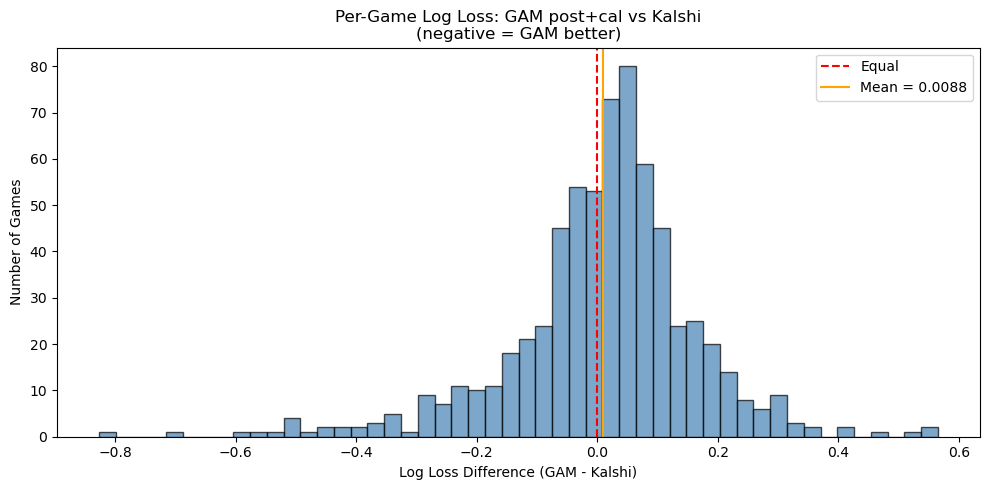

In [11]:
# -- Histogram: per-game log loss difference --

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gm['ll_diff'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal')
ax.axvline(gm['ll_diff'].mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean = {gm["ll_diff"].mean():.4f}')
ax.set_xlabel('Log Loss Difference (GAM - Kalshi)')
ax.set_ylabel('Number of Games')
ax.set_title('Per-Game Log Loss: GAM post+cal vs Kalshi\n(negative = GAM better)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 6 -- Reliability Diagrams

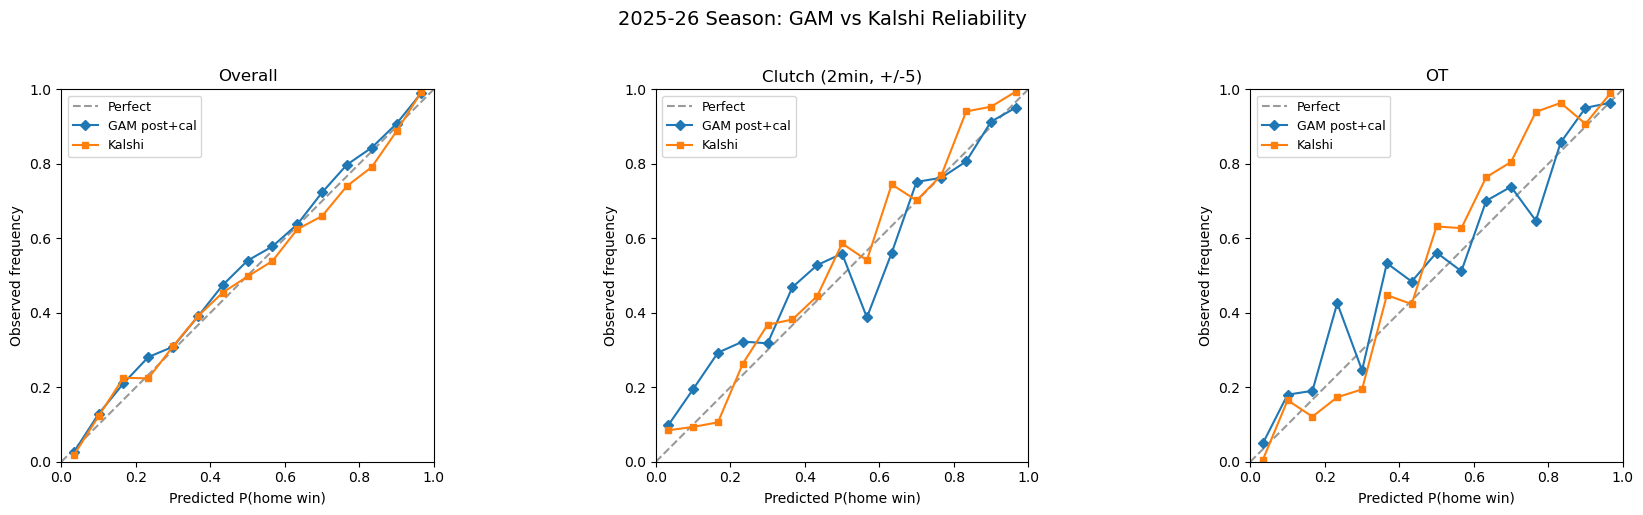

In [12]:
# -- Reliability diagrams --

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_slices = [
    ('Overall', df),
    ('Clutch (2min, +/-5)', df[(df['t_reg_remaining'] <= 120) &
                                (df['score_diff'].abs() <= 5) &
                                (df['is_ot'] == 0)]),
    ('OT', df[df['is_ot'] == 1]),
]

for ax, (title, sub) in zip(axes, plot_slices):
    if sub.empty:
        ax.set_title(f'{title} -- no data')
        continue
    y_s = sub['y'].values.astype(float)
    w_s = sub['sample_weight'].values.astype(float)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect')
    for col, label, marker in [
        ('p_gam_post_cal', 'GAM post+cal', 'D'),
        ('p_kalshi', 'Kalshi', 's'),
    ]:
        c, e, _ = reliability_curve(y_s, sub[col].values, w_s, n_bins=15)
        ax.plot(c, e, f'{marker}-', markersize=5, label=label)
    ax.set_title(title)
    ax.set_xlabel('Predicted P(home win)')
    ax.set_ylabel('Observed frequency')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')

plt.suptitle('2025-26 Season: GAM vs Kalshi Reliability', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 7 -- Sample Game Traces

Plot individual games showing GAM vs Kalshi probability traces.

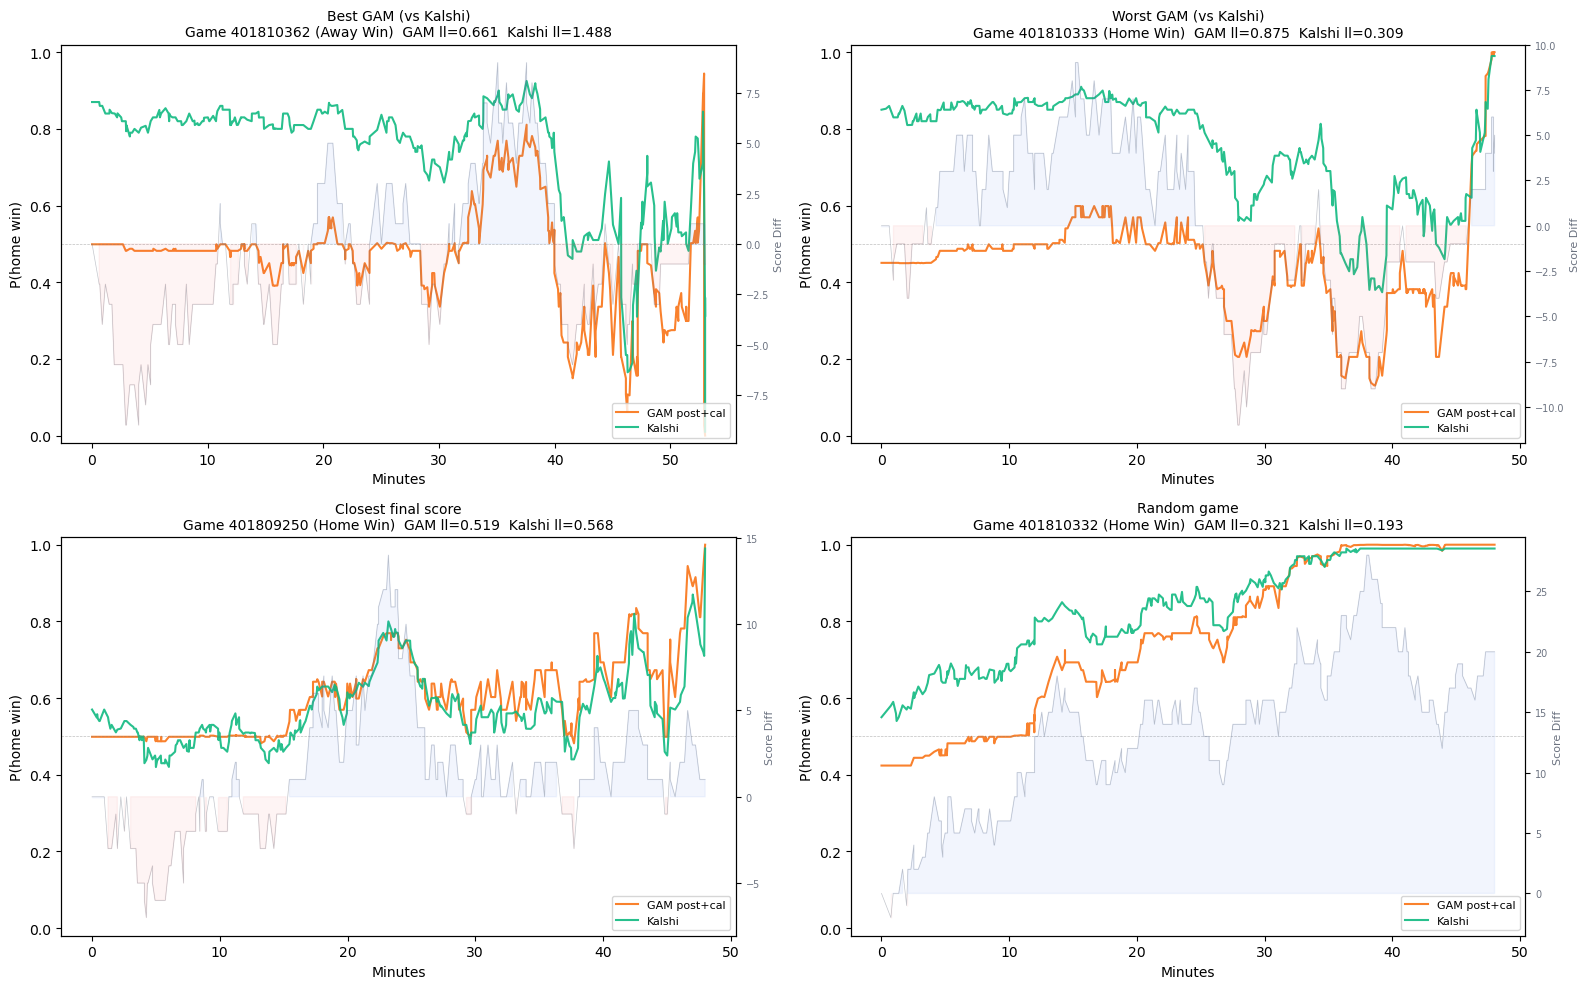

In [13]:
# -- Sample game traces --

np.random.seed(42)
best_gam_gid = gm.loc[gm['ll_diff'].idxmin(), 'game_id']
worst_gam_gid = gm.loc[gm['ll_diff'].idxmax(), 'game_id']
random_gid = gm.sample(1)['game_id'].values[0]

# Close game: smallest final score diff
final_scores = df.groupby('game_id').last()[['score_diff', 'y']].reset_index()
final_scores['abs_diff'] = final_scores['score_diff'].abs()
close_gid = final_scores.loc[final_scores['abs_diff'].idxmin(), 'game_id']

sample_games = [
    (best_gam_gid, 'Best GAM (vs Kalshi)'),
    (worst_gam_gid, 'Worst GAM (vs Kalshi)'),
    (close_gid, 'Closest final score'),
    (random_gid, 'Random game'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (gid, label) in zip(axes.flat, sample_games):
    g = df[df['game_id'] == gid].copy()
    elapsed_min = g['elapsed'].values / 60.0
    outcome = 'Home Win' if g['y'].iloc[0] == 1 else 'Away Win'

    ax.plot(elapsed_min, g['p_gam_post_cal'], label='GAM post+cal',
            color='#f97316', linewidth=1.5, alpha=0.9)
    ax.plot(elapsed_min, g['p_kalshi'], label='Kalshi',
            color='#10b981', linewidth=1.5, alpha=0.9)
    ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

    ax2 = ax.twinx()
    ax2.fill_between(elapsed_min, g['score_diff'], 0,
                     where=(g['score_diff'] >= 0), color='#2563eb', alpha=0.06)
    ax2.fill_between(elapsed_min, g['score_diff'], 0,
                     where=(g['score_diff'] < 0), color='#ef4444', alpha=0.06)
    ax2.plot(elapsed_min, g['score_diff'], color='#6b7280', linewidth=0.5, alpha=0.4)
    ax2.set_ylabel('Score Diff', fontsize=8, color='#6b7280')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='#6b7280')

    ll_gam = gm.loc[gm['game_id'] == gid, 'll_GAM post+cal'].values[0]
    ll_kal = gm.loc[gm['game_id'] == gid, 'll_Kalshi'].values[0]

    ax.set_title(f'{label}\nGame {gid} ({outcome})  GAM ll={ll_gam:.3f}  Kalshi ll={ll_kal:.3f}',
                 fontsize=10)
    ax.set_xlabel('Minutes')
    ax.set_ylabel('P(home win)')
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## Summary

Key takeaways from comparing GAM posterior model vs Kalshi market odds across the 2025-26 season.